In [1]:
# Environment + LLM setup
import os
from dotenv import load_dotenv

load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")


c:\Users\harsu\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
result = llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user just says "Hello". We need to respond appropriately. There\'s no special instruction. We should greet back.'}, response_metadata={'token_usage': {'completion_tokens': 42, 'prompt_tokens': 72, 'total_tokens': 114, 'completion_time': 0.092646518, 'prompt_time': 0.003014265, 'queue_time': 0.035654882, 'total_time': 0.095660783, 'completion_tokens_details': {'reasoning_tokens': 24}}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_0708ac49a5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019bb3e0-6e91-7e80-9a09-77fddd412293-0', usage_metadata={'input_tokens': 72, 'output_tokens': 42, 'total_tokens': 114, 'output_token_details': {'reasoning': 24}})

In [4]:
# Imports for structured planning + graph state
from typing import Annotated, List
import operator
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

In [5]:
# Blog outline + blog meta schemas 

class Section(BaseModel):
    name: str = Field(description="Name for this section of the blog post")
    description: str = Field(description="Brief overview of what this blog section will cover")

class Sections(BaseModel):
    sections: List[Section] = Field(description="Sections of the blog post")

class BlogMeta(BaseModel):
    title: str = Field(description="A compelling, clear blog post title")
    tldr: str = Field(description="A short TL;DR summary (2-4 sentences)")


In [6]:
# Planners 
outline_planner = llm.with_structured_output(Sections)
meta_planner = llm.with_structured_output(BlogMeta)


In [12]:
# LangGraph constants + State definitions
from langgraph.constants import Send

class State(TypedDict):
    topic: str
    title: str
    tldr: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]
    final_blog: str

class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


C:\Users\harsu\AppData\Local\Temp\ipykernel_5540\3073068911.py:2: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [13]:
# Nodes (orchestrator + workers + synthesizer)

def orchestrator(state: State):
    """Orchestrator: generates blog title, TL;DR, and an outline."""

    # 1) Generate title + TL;DR
    meta = meta_planner.invoke(
        [
            SystemMessage(content="You are a technical blog editor. Produce a strong title and a concise TL;DR."),
            HumanMessage(content=f"Blog topic: {state['topic']}"),
        ]
    )

    # 2) Generate outline (sections)
    outline = outline_planner.invoke(
        [
            SystemMessage(
                content=(
                    "Create a detailed outline for a technical tutorial blog post. "
                    "Return 5–8 sections. Each section must be practical and logically ordered."
                )
            ),
            HumanMessage(content=f"Blog topic: {state['topic']}"),
        ]
    )

    print("Blog Meta:", meta)
    print("Blog Sections:", outline)

    return {
        "title": meta.title,
        "tldr": meta.tldr,
        "sections": outline.sections,
    }


def llm_call(state: WorkerState):
    """Worker: writes a single blog section."""

    section = llm.invoke(
        [
            SystemMessage(
                content=(
                    "Write a blog section for a technical tutorial. "
                    "No preamble. Use markdown. Be concrete and instructional. "
                    "Assume the reader is a developer. Do not add SEO metadata."
                )
            ),
            HumanMessage(
                content=(
                    f"Section name: {state['section'].name}\n"
                    f"Section description: {state['section'].description}\n\n"
                    "Write this section now."
                )
            ),
        ]
    )

    return {"completed_sections": [section.content]}


def assign_workers(state: State):
    """Create one worker per section."""
    return [Send("llm_call", {"section": s}) for s in state["sections"]]


def synthesizer(state: State):
    """Combine title + TL;DR + all sections into a final blog markdown doc."""

    completed_sections = state["completed_sections"]
    body = "\n\n---\n\n".join(completed_sections)

    final_blog = f"# {state['title']}\n\n**TL;DR:** {state['tldr']}\n\n---\n\n{body}"
    return {"final_blog": final_blog}


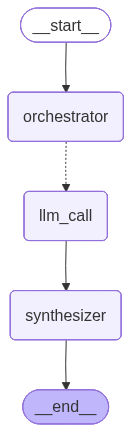

In [14]:
# Build workflow
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)

builder.add_node("orchestrator", orchestrator)
builder.add_node("llm_call", llm_call)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "orchestrator")
builder.add_conditional_edges("orchestrator", assign_workers, ["llm_call"])
builder.add_edge("llm_call", "synthesizer")
builder.add_edge("synthesizer", END)

workflow = builder.compile()

display(Image(workflow.get_graph().draw_mermaid_png()))


In [15]:
state = workflow.invoke({"topic": "Introduction to Agentic AI"})
state.keys()

Blog Meta: title='Agentic AI 101: How Autonomous Agents Are Redefining Intelligent Systems' tldr='Agentic AI introduces self‑directing artificial agents that can set goals, plan actions, and adapt in dynamic environments. This post explains the core concepts, key technologies, and real‑world examples, and outlines the challenges and future prospects of building truly autonomous AI systems.'
Blog Sections: sections=[Section(name='What is Agentic AI?', description='Define agentic AI, contrast it with traditional AI models, and explain why autonomy and goal‑directed behavior matter for real‑world applications.'), Section(name='Core Concepts and Architecture', description='Introduce the building blocks of an autonomous agent: LLM core, policy/decision module, memory, tool‑use, and feedback loops. Include a simple diagram of the data flow.'), Section(name='Setting Up the Development Environment', description='Walk through installing Python, required libraries (e.g., LangChain, OpenAI SDK, L

dict_keys(['topic', 'title', 'tldr', 'sections', 'completed_sections', 'final_blog'])

In [16]:
# Render final blog
from IPython.display import Markdown

Markdown(state["final_blog"])


# Agentic AI 101: How Autonomous Agents Are Redefining Intelligent Systems

**TL;DR:** Agentic AI introduces self‑directing artificial agents that can set goals, plan actions, and adapt in dynamic environments. This post explains the core concepts, key technologies, and real‑world examples, and outlines the challenges and future prospects of building truly autonomous AI systems.

---

## What is Agentic AI?

Agentic AI refers to a class of systems that **act autonomously** to achieve **explicitly defined goals** in dynamic environments. Unlike conventional AI models that are passive function approximators (e.g., a classifier that maps an input image to a label), an agentic AI system **perceives**, **decides**, and **acts** in a loop:

```
while not goal_met:
    observation = sense_environment()
    state       = update_state(observation)
    action      = plan(state, goal)
    execute(action)
```

### Key characteristics

| Characteristic | Traditional AI (e.g., static models) | Agentic AI |
|----------------|--------------------------------------|------------|
| **Execution model** | One‑shot inference (`f(x) → y`) | Continuous sense‑plan‑act loop |
| **Goal handling** | Implicit (learned from training data) | Explicit, configurable at runtime |
| **Adaptivity** | Fixed after training (unless retrained) | Can re‑plan on the fly based on new observations |
| **Agency** | No self‑initiated behavior | Self‑directed, can initiate actions without external prompts |
| **Temporal reasoning** | Typically stateless or limited to fixed windows | Maintains and updates internal state across time |

### Contrasting examples

| Scenario | Traditional AI solution | Agentic AI solution |
|----------|------------------------|---------------------|
| **Customer support bot** | A retrieval‑based chatbot that returns the best pre‑written answer for each user query. | A conversational agent that tracks the conversation context, decides when to ask clarifying questions, and can proactively offer relevant resources before the user asks. |
| **Warehouse robot** | A motion‑planning model that takes a fixed start/end pair and outputs a trajectory. | An autonomous robot that continuously monitors obstacles, re‑plans routes when aisles become blocked, and decides when to recharge based on battery level and task priority. |
| **Recommendation engine** | A matrix‑factorization model that scores items for a user snapshot. | An agent that observes user behavior over time, sets a short‑term goal (e.g., “increase session length”), and dynamically selects content to steer the user toward that goal. |

### Why autonomy and goal‑directed behavior matter

1. **Real‑world variability** – Production environments are noisy and unpredictable. An autonomous loop lets the system react to sensor failures, network latency spikes, or sudden changes in user intent without human intervention.

2. **Scalability of human oversight** – Embedding explicit goals (e.g., “maintain 99.9 % uptime”, “keep inventory turnover > 5 days”) lets operators adjust system behavior by tweaking goal parameters instead of rewriting model code.

3. **Safety and compliance** – Goal constraints can be encoded as hard limits (e.g., “never exceed speed = 5 m/s”). The agent’s planner can enforce these constraints at runtime, reducing reliance on post‑hoc monitoring.

4. **Efficiency through self‑optimization** – An agent can allocate resources (CPU, bandwidth, battery) based on its current objective, leading to lower operational costs compared to static pipelines that over‑provision for worst‑case scenarios.

5. **User‑centric experiences** – By maintaining a persistent state and a clear objective (e.g., “help the user complete a purchase”), the system can anticipate needs, reduce friction, and deliver more personalized outcomes.

### Quick starter: turning a classifier into a simple agent

Below is a minimal Python skeleton that upgrades a static classifier (`predict_label`) into an agent that pursues a goal—*maximizing the number of “positive” predictions*—while respecting a rate limit.

```python
import time
from collections import deque

# Existing model
def predict_label(data):
    # ... heavy ML inference ...
    return "positive" if model.predict(data) > 0.7 else "negative"

# Agent configuration
GOAL = "max_positive"
MAX_CALLS_PER_MIN = 30

# Simple rate limiter
call_log = deque(maxlen=MAX_CALLS_PER_MIN)

def can_call():
    now = time.time()
    # Drop timestamps older than 60 s
    while call_log and now - call_log[0] > 60:
        call_log.popleft()
    return len(call_log) < MAX_CALLS_PER_MIN

def sense():
    # Pull next data point from a queue, sensor, etc.
    return data_queue.get()

def act(prediction):
    if prediction == "positive":
        # Do something goal‑directed, e.g., trigger downstream workflow
        trigger_workflow()
    else:
        # Optionally log or ignore
        pass

def agent_loop():
    while True:
        if not can_call():
            time.sleep(1)            # back‑off until rate limit lifts
            continue

        observation = sense()
        prediction = predict_label(observation)
        call_log.append(time.time())
        act(prediction)

# Run the agent
if __name__ == "__main__":
    agent_loop()
```

*What changed?*  
- **Loop** – The code continuously senses data instead of a single batch call.  
- **Goal** – The `act` function encodes a concrete objective (“do something when the prediction is positive”).  
- **Autonomy** – The agent enforces a runtime constraint (`MAX_CALLS_PER_MIN`) without external supervision.

By structuring your system around this sense‑plan‑act paradigm, you transition from a passive model to an **agentic AI** capable of operating reliably in the messy, goal‑driven world of production software.

---

## Core Concepts and Architecture

In an autonomous agent the **LLM core** does not act alone. It is orchestrated by a lightweight **policy/decision module**, interacts with **memory**, calls external **tools**, and continuously refines its behavior through **feedback loops**. Understanding how these pieces fit together is essential before you start wiring your own agent.

---

### 1. Building‑block Overview

| Component | Responsibility | Typical Implementation |
|-----------|----------------|------------------------|
| **LLM Core** | Generates natural‑language output (or intermediate representations) given a prompt. | OpenAI `gpt‑4o`, Anthropic `claude-3`, locally hosted Llama 3, etc. |
| **Policy / Decision Module** | Determines *what* the agent should do next (e.g., “invoke a tool”, “store to memory”, “ask the user”). Often a rule‑engine or a tiny classifier that consumes the LLM output. | Simple Python function, a decision‑tree, or a second‑stage LLM prompt that returns a structured action. |
| **Memory** | Persists context across turns: facts, plans, results of tool calls. Enables the agent to be stateful. | Vector store (FAISS, Chroma), key‑value DB (Redis), or a simple in‑memory list for prototyping. |
| **Tool‑Use** | Executes external capabilities (APIs, code execution, web search, etc.) and returns results to the LLM. | Wrapper classes exposing `run(params)`; can be async. |
| **Feedback Loops** | Collects signals (user ratings, execution errors, success metrics) and feeds them back into the policy or LLM prompt for self‑improvement. | Logging → reward model → prompt adjustment; or online RLHF style updates. |

---

### 2. Data Flow Diagram

```mermaid
flowchart TD
    UserInput[User Input] -->|Prompt| LLMCore[LLM Core]
    LLMCore -->|Raw text / JSON| Policy[Policy / Decision Module]
    Policy -->|Action Type| Decision{Decision}
    Decision -->|Tool Call| Tool[Tool‑Use]
    Decision -->|Store| Memory[Memory]
    Decision -->|Reply| Response[Agent Reply]
    Tool -->|Result| LLMCore
    Memory -->|Context| LLMCore
    Response -->|Send to User| UserInput
    subgraph Feedback
        Response -->|Feedback Signal| FeedbackLoop[Feedback Loops]
        FeedbackLoop -->|Update| Policy
        FeedbackLoop -->|Update| LLMCore
    end
```

*Arrows indicate the direction of data. The LLM core can be invoked multiple times per turn (e.g., once to generate a plan, again after a tool returns a result).*

---

### 3. Minimal Reference Implementation (Python)

```python
import json
from typing import Any, Dict

# --- 1. LLM Core -------------------------------------------------
def call_llm(messages: list[Dict[str, str]]) -> str:
    # Replace with your provider's SDK; this stub returns a JSON string.
    # Example prompt: "You are an autonomous agent. Output {action, args}."
    response = openai.ChatCompletion.create(
        model="gpt-4o-mini",
        messages=messages,
        temperature=0.0,
    )
    return response.choices[0].message.content

# --- 2. Policy / Decision -----------------------------------------
def decide(llm_output: str) -> Dict[str, Any]:
    """
    Expect the LLM to emit a JSON payload:
    {"action": "search_web", "args": {"query": "latest Python 3.12 features"}}
    """
    try:
        payload = json.loads(llm_output)
    except json.JSONDecodeError:
        # Fallback: treat as plain text reply
        return {"action": "reply", "args": {"text": llm_output}}
    return payload

# --- 3. Memory ---------------------------------------------------
class SimpleMemory:
    def __init__(self):
        self.history = []   # List of (role, content)

    def add(self, role: str, content: str):
        self.history.append((role, content))

    def as_messages(self) -> list[Dict[str, str]]:
        return [{"role": r, "content": c} for r, c in self.history]

memory = SimpleMemory()

# --- 4. Tool‑Use -------------------------------------------------
def search_web(query: str) -> str:
    # Placeholder – in real code call a search API.
    return f"Results for '{query}' (simulated)."

TOOLS = {
    "search_web": search_web,
    # add more tools here
}

# --- 5. Feedback Loop (very simple) ------------------------------
def log_feedback(action: str, success: bool):
    # Persist to a DB or send to an analytics pipeline.
    print(f"[feedback] {action=} success={success}")

# --- Main loop ---------------------------------------------------
def agent_step(user_msg: str):
    # 1️⃣ Add user message to memory
    memory.add("user", user_msg)

    # 2️⃣ Call LLM with accumulated context
    llm_output = call_llm(memory.as_messages())

    # 3️⃣ Policy decides what to do
    decision = decide(llm_output)

    # 4️⃣ Dispatch based on action
    action = decision["action"]
    args = decision.get("args", {})

    if action in TOOLS:
        result = TOOLS[action](**args)          # tool execution
        memory.add("assistant", f"Tool result: {result}")
        log_feedback(action, True)
    elif action == "reply":
        reply = args["text"]
        memory.add("assistant", reply)
        log_feedback("reply", True)
    else:
        # Unknown action – fallback to plain reply
        memory.add("assistant", llm_output)
        log_feedback("fallback", False)

    # 5️⃣ Return the latest assistant message
    return memory.history[-1][1]

# Example usage
if __name__ == "__main__":
    print(agent_step("What are the newest features in Python 3.12?"))
```

**Key takeaways from the code**

1. **LLM ↔ Memory** – The `memory.as_messages()` function builds the prompt each turn, ensuring the LLM sees the full conversation.
2. **Policy Layer** – `decide()` parses the LLM’s JSON output into a deterministic action, separating generation from execution.
3. **Tool Dispatch** – A simple `TOOLS` registry maps action names to Python callables; you can expand this to async HTTP clients, Docker containers, etc.
4. **Feedback** – Even a one‑line `log_feedback` call can be hooked into a monitoring system that later informs prompt engineering or fine‑tuning.

---

### 4. What to Customize Next

| Area | Why it matters | Quick start tweak |
|------|----------------|-------------------|
| **Prompt Engineering** | Guides the LLM to emit structured actions reliably. | Add a system message: `You must output a JSON object with keys "action" and "args".` |
| **Policy Sophistication** | Handles ambiguous or multi‑step plans. | Replace `decide()` with a tiny classifier (e.g., `sklearn` logistic regression) that looks at the raw text before parsing JSON. |
| **Memory Backend** | Scalability and retrieval quality. | Swap `SimpleMemory` for a vector store (e.g., `Chroma`) and embed each turn with `text‑embedding‑3‑large`. |
| **Tool Suite** | Extends the agent’s capabilities. | Add a `run_python` tool that executes sandboxed code and returns stdout. |
| **Feedback Loop** | Drives continuous improvement. | Store user thumbs‑up/down in a DB, then periodically fine‑tune the LLM on successful trajectories. |

By keeping these components loosely coupled—LLM core, decision policy, memory, tools, and feedback—you can iterate on each part independently, replace technologies as they evolve, and maintain a clean, testable architecture for your autonomous agents.

---

## Setting Up the Development Environment

Below is a step‑by‑step guide to get a clean, reproducible workspace ready for building LangChain‑based applications with OpenAI and LangGraph.

---

### 1. Install Python (≥ 3.9)

```bash
# macOS / Linux (using Homebrew)
brew install python@3.11   # or any version >= 3.9

# Windows (using Chocolatey)
choco install python --version=3.11.0
```

* Verify the installation:

```bash
python3 --version   # should print something like "Python 3.11.x"
```

> **Tip:** If you already have a Python version manager (e.g., `pyenv` or `asdf`), use it to install the exact version you need and set it as the local version for the project directory.

---

### 2. Create a Project Directory

```bash
mkdir langchain-demo && cd langchain-demo
```

---

### 3. Set Up a Virtual Environment

Using the built‑in `venv` module guarantees that the environment is portable across machines.

```bash
python3 -m venv .venv
source .venv/bin/activate   # macOS / Linux
# .venv\Scripts\activate      # Windows PowerShell
```

> **Why a virtual env?** It isolates your dependencies from the global Python installation, making the project reproducible and avoiding version clashes.

---

### 4. Pin the Python Version (Optional but Recommended)

If you’re using `pyenv` or `asdf`, record the exact interpreter:

```bash
pyenv local 3.11.5   # creates a .python-version file
# or
asdf local python 3.11.5
```

---

### 5. Install Required Libraries

Create a `requirements.txt` file to lock versions:

```text
langchain==0.2.5
openai==1.30.0
langgraph==0.0.12
python-dotenv==1.0.1
```

Then install:

```bash
pip install --upgrade pip
pip install -r requirements.txt
```

*If you prefer Poetry or Pipenv, replace the `requirements.txt` workflow with the appropriate lockfile commands.*

---

### 6. Configure API Keys Securely

Both OpenAI and LangGraph require secret keys. Store them in a `.env` file that you **never** commit to version control.

```bash
# .env (create this file in the project root)
OPENAI_API_KEY=sk-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
LANGGRAPH_API_KEY=lgp-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
```

Add the file to `.gitignore`:

```bash
echo ".env" >> .gitignore
```

Load the variables in your code with `python-dotenv`:

```python
# config.py
from dotenv import load_dotenv
import os

load_dotenv()  # pulls values from .env into os.environ

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
LANGGRAPH_API_KEY = os.getenv("LANGGRAPH_API_KEY")
```

---

### 7. Verify the Installation

Create a quick sanity‑check script:

```python
# sanity_check.py
from langchain import OpenAI
from langgraph import Graph

print("LangChain version:", OpenAI.__module__)
print("LangGraph import succeeded")
```

Run it:

```bash
python sanity_check.py
```

If no import errors appear, your environment is ready.

---

### 8. Freeze the Environment (for reproducibility)

After confirming everything works, capture the exact dependency graph:

```bash
pip freeze > frozen_requirements.txt
```

Commit `frozen_requirements.txt` alongside `requirements.txt`. Future collaborators can recreate the environment with:

```bash
pip install -r frozen_requirements.txt
```

---

### 9. (Optional) Dockerize the Setup

If you want an even more portable environment, add a minimal Dockerfile:

```dockerfile
# Dockerfile
FROM python:3.11-slim

WORKDIR /app
COPY . /app
RUN python -m venv /opt/venv && \
    /opt/venv/bin/pip install --upgrade pip && \
    /opt/venv/bin/pip install -r frozen_requirements.txt

ENV PATH="/opt/venv/bin:$PATH"
CMD ["python", "your_main_script.py"]
```

Build and run:

```bash
docker build -t langchain-demo .
docker run --rm -e OPENAI_API_KEY=$OPENAI_API_KEY -e LANGGRAPH_API_KEY=$LANGGRAPH_API_KEY langchain-demo
```

---

### TL;DR Checklist

| Step | Command |
|------|---------|
| Install Python | `brew install python@3.11` / `choco install python` |
| Create dir | `mkdir langchain-demo && cd langchain-demo` |
| Virtual env | `python3 -m venv .venv && source .venv/bin/activate` |
| Pin deps | `echo "langchain==0.2.5\nopenai==1.30.0\nlanggraph==0.0.12\npython-dotenv==1.0.1" > requirements.txt` |
| Install deps | `pip install -r requirements.txt` |
| Add .env | `echo "OPENAI_API_KEY=...\nLANGGRAPH_API_KEY=..." > .env` |
| Verify | `python sanity_check.py` |
| Freeze | `pip freeze > frozen_requirements.txt` |

You now have a clean, reproducible development environment ready for the next sections of the tutorial. Happy coding!

---

## Building Your First Agentic AI

In this section you’ll assemble a **minimal goal‑oriented agent** that can:

1. Receive a natural‑language query from a user.  
2. Decide whether it needs to gather external information.  
3. Invoke a simple web‑search tool when required.  
4. Return a concise answer to the user.

The implementation uses **Python**, the **OpenAI** API, and a tiny wrapper around a public search endpoint (SerpAPI). All code is runnable as‑is once the prerequisites are installed.

---  

### 1. Prerequisites  

| Item | Why we need it | Install command |
|------|----------------|-----------------|
| Python ≥ 3.9 | Core language | (already installed) |
| `openai` library | Calls to GPT‑4/3.5 | `pip install openai` |
| `pydantic` | Structured tool schema | `pip install pydantic` |
| `requests` | HTTP calls to the search API | `pip install requests` |
| **SerpAPI** key (free tier) | Real‑world web search | Sign up at https://serpapi.com/ |

> **Tip:** Store your API keys in environment variables (`OPENAI_API_KEY`, `SERPAPI_API_KEY`) – never hard‑code them.

```bash
export OPENAI_API_KEY="sk-..."
export SERPAPI_API_KEY="your-serpapi-key"
```

---  

### 2. Define the Search Tool  

We expose a single function `search(query: str) -> str` that returns the top result snippet. The agent will treat this as a **tool** it can call.

```python
# search_tool.py
import os
import requests
from typing import List
from pydantic import BaseModel

SERPAPI_ENDPOINT = "https://serpapi.com/search"

class SearchResult(BaseModel):
    title: str
    snippet: str
    link: str

def search(query: str, num_results: int = 3) -> str:
    """Perform a web search via SerpAPI and return a formatted string."""
    params = {
        "engine": "google",
        "q": query,
        "api_key": os.getenv("SERPAPI_API_KEY"),
        "num": num_results,
    }
    resp = requests.get(SERPAPI_ENDPOINT, params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()

    results: List[SearchResult] = []
    for entry in data.get("organic_results", [])[:num_results]:
        results.append(
            SearchResult(
                title=entry.get("title", "No title"),
                snippet=entry.get("snippet", "No snippet"),
                link=entry.get("link", ""),
            )
        )

    # Build a human‑readable block for the LLM
    formatted = "\n".join(
        f"{i+1}. **{r.title}**\n   {r.snippet}\n   {r.link}"
        for i, r in enumerate(results)
    )
    return formatted or "No results found."
```

---  

### 3. Prompt Template & Agent Logic  

The agent follows a **ReAct** pattern: *Reason → Act → Observe → Repeat*.  
We give the LLM a short system prompt that describes the available tool and the expected loop.

```python
# agent.py
import os
import json
import openai
from search_tool import search

openai.api_key = os.getenv("OPENAI_API_KEY")

SYSTEM_PROMPT = """
You are an autonomous assistant that can answer user questions. 
If you lack sufficient information, you may call the `search` tool.

**Tool definition**
- name: search
- description: Perform a web search and return the top 3 result snippets.
- usage: `search("<query>")`

**Interaction protocol**
1. Think about the user request.
2. If you need external data, output a JSON block:
   ```json
   {"action": "search", "input": "<search query>"}
   ```
3. When you receive the tool's output, incorporate it and either:
   - call another tool, or
   - produce the final answer in plain text.
Never output the JSON block together with a final answer.
"""

def call_llm(messages: list[dict]) -> dict:
    """Wrap the OpenAI chat completion call."""
    response = openai.ChatCompletion.create(
        model="gpt-4o-mini",   # or gpt-3.5-turbo if you prefer
        messages=messages,
        temperature=0.0,
    )
    return response["choices"][0]["message"]
```

### 4. The ReAct Loop  

```python
def run_agent(user_query: str, max_steps: int = 5) -> str:
    # Initialise the message history with the system prompt and the user query
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_query},
    ]

    for step in range(max_steps):
        # 1️⃣ LLM decides what to do next
        llm_msg = call_llm(messages)
        content = llm_msg["content"].strip()
        messages.append(llm_msg)  # keep history for context

        # 2️⃣ Check if the LLM wants to use a tool
        try:
            # The LLM is instructed to emit a pure JSON block when acting.
            action = json.loads(content)
            if isinstance(action, dict) and action.get("action") == "search":
                query = action["input"]
                # 3️⃣ Execute the tool
                tool_output = search(query)
                # 4️⃣ Feed the observation back to the LLM
                observation_msg = {
                    "role": "assistant",
                    "content": f"Tool `search` returned:\n{tool_output}",
                }
                messages.append(observation_msg)
                continue  # go to next iteration
        except json.JSONDecodeError:
            # Not a JSON action → assume final answer
            return content

    # If we exceed max_steps, fall back to the last LLM output
    return "I couldn't resolve the request within the allowed steps."
```

---  

### 5. Test the Agent  

```python
if __name__ == "__main__":
    queries = [
        "What is the capital of New Zealand?",
        "Who won the Best Actor Oscar in 2023?",
        "Explain the main differences between Rust and Go.",
    ]

    for q in queries:
        print(f"\n🗣️ User: {q}")
        answer = run_agent(q)
        print(f"🤖 Agent: {answer}")
```

**Expected behaviour**

| Query | Agent flow |
|-------|------------|
| Capital of New Zealand | The LLM knows the fact → returns **Wellington** without calling `search`. |
| Best Actor Oscar 2023 | The LLM may not have the latest data → emits a `search` action → receives snippets → synthesises the winner (e.g., *Brendan Fraser*). |
| Rust vs Go | The LLM can answer from its training data → returns a concise comparison. |

---  

### 6. Why This Works  

1. **Goal‑oriented prompt** – The system message tells the model its *goal* (answer the user) and the *means* (the `search` tool).  
2. **Explicit JSON contract** – By forcing tool calls into a strict JSON block, we can reliably parse the intent without ambiguous free‑form text.  
3. **Iterative observation** – Each tool output is fed back as a new assistant message, preserving the chain of thought.  
4. **Deterministic temperature** – `temperature=0.0` makes the reasoning reproducible, which is crucial for debugging agents.

---  

### 7. Extending the Agent  

| Feature | How to add |
|---------|------------|
| **Multiple tools** (e.g., calculator, file reader) | Add more entries to the system prompt and extend the `if` block in `run_agent` to dispatch based on `action`. |
| **Memory across sessions** | Store `messages` in a DB or cache and prepend them when a new query arrives. |
| **Streaming responses** | Use `openai.ChatCompletion.create(..., stream=True)` and forward each chunk to the client as it arrives. |
| **Safety filters** | Insert a post‑processing step that checks the final answer for policy violations before returning it. |

---  

### 8. Common Pitfalls & Debugging Tips  

| Symptom | Likely cause | Fix |
|---------|--------------|-----|
| Agent returns “I couldn't resolve the request…” | `max_steps` too low or the LLM never emits a final answer. | Increase `max_steps` or add a fallback prompt that nudges the model toward answering after a tool call. |
| JSON parsing fails | LLM added extra text around the JSON block. | Tighten the system prompt: “Output **only** the JSON block, no surrounding text.” |
| Search returns “No results found.” | Query too specific or API key missing/invalid. | Verify `SERPAPI_API_KEY` is set; try a broader query. |
| Rate‑limit errors from OpenAI | Too many rapid calls in a loop. | Insert a short `time.sleep(0.2)` between iterations or batch multiple user queries. |

---  

### 9. Full Source (single file)  

If you prefer a single‑file demo, copy the following into `agent_demo.py`. It contains the tool, prompts, and loop all together.

```python
import os, json, time, requests
import openai
from pydantic import BaseModel
from typing import List

# ---------- Config ----------
openai.api_key = os.getenv("OPENAI_API_KEY")
SERPAPI_KEY = os.getenv("SERPAPI_API_KEY")
# ---------------------------

# ---- Search tool ----
class SearchResult(BaseModel):
    title: str
    snippet: str
    link: str

def search(query: str, n: int = 3) -> str:
    params = {
        "engine": "google",
        "q": query,
        "api_key": SERPAPI_KEY,
        "num": n,
    }
    r = requests.get("https://serpapi.com/search", params=params, timeout=10)
    r.raise_for_status()
    data = r.json()
    results: List[SearchResult] = [
        SearchResult(
            title=e.get("title", "No title"),
            snippet=e.get("snippet", "No snippet"),
            link=e.get("link", ""),
        )
        for e in data.get("organic_results", [])[:n]
    ]
    if not results:
        return "No results found."
    return "\n".join(
        f"{i+1}. **{r.title}**\n   {r.snippet}\n   {r.link}"
        for i, r in enumerate(results)
    )
# ---------------------

# ---- Agent prompt ----
SYSTEM = """
You are an autonomous assistant that can answer user questions. 
If you lack sufficient information, you may call the `search` tool.

**Tool definition**
- name: search
- description: Perform a web search and return the top 3 result snippets.
- usage: `search("<query>")`

**Interaction protocol**
1. Think about the request.
2. If external data is needed, output ONLY a JSON block:
   ```json
   {"action": "search", "input": "<search query>"}
   ```
3. When you receive the tool output, incorporate it and either call another tool or give the final answer in plain text.
Never mix the JSON block with a final answer.
"""
# ---------------------

def llm(messages: List[dict]) -> dict:
    resp = openai.ChatCompletion.create(
        model="gpt-4o-mini",
        messages=messages,
        temperature=0.0,
    )
    return resp["choices"][0]["message"]

def run(query: str, max_steps: int = 5) -> str:
    msgs = [
        {"role": "system", "content": SYSTEM},
        {"role": "user", "content": query},
    ]

    for _ in range(max_steps):
        msg = llm(msgs)
        msgs.append(msg)
        txt = msg["content"].strip()

        # Try to parse a tool request
        try:
            act = json.loads(txt)
            if isinstance(act, dict) and act.get("action") == "search":
                tool_input = act["input"]
                out = search(tool_input)
                msgs.append(
                    {"role": "assistant", "content": f"Tool `search` returned:\n{out}"}
                )
                continue
        except json.JSONDecodeError:
            pass  # Not a JSON action → final answer

        return txt  # final answer

    return "Failed to produce an answer within the step limit."

# ---- Demo ----
if __name__ == "__main__":
    for q in [
        "What is the capital of New Zealand?",
        "Who won the Best Actor Oscar in 2023?",
        "Explain the main differences between Rust and Go.",
    ]:
        print("\n🗣️", q)
        print("🤖", run(q))
        time.sleep(0.2)  # be polite to the APIs
```

Run it:

```bash
python agent_demo.py
```

You should see the agent answer each question, invoking the web search only when necessary.

---  

**Congratulations!** You now have a functional, goal‑oriented AI agent that can reason, call a tool, and synthesize a final response. From here you can plug in richer tools (databases, code execution, etc.) and evolve the architecture into a full‑featured autonomous system. Happy hacking!

---

## Managing State and Memory

### 1. Short‑Term vs. Long‑Term Memory

| Aspect | Short‑Term Memory | Long‑Term Memory |
|--------|-------------------|------------------|
| **Scope** | Current conversation turn (or a few recent turns). | Knowledge that survives across sessions or many turns. |
| **Lifetime** | Disappears once the turn ends or the buffer is flushed. | Persisted to disk, DB, or vector store; survives restarts. |
| **Typical Use‑Case** | Maintaining context for a single request‑response cycle (e.g., “What’s the weather in **Paris**?” → “Tomorrow?”). | Storing facts, user preferences, or embeddings that the model can retrieve later (e.g., “User prefers dark theme”). |
| **Implementation** | In‑memory list/dict, LLM chat history, or a sliding window buffer. | Vector database, key‑value store, checkpoint files, or a hybrid cache. |

> **Rule of thumb:** Keep the short‑term buffer as small as possible to stay within token limits, and push anything you might need later into a long‑term store.

---

### 2. Persisting Context Across Turns

#### 2.1. Simple In‑Memory Buffer (Short‑Term)

```python
# Example: a rolling window of the last 5 messages
from collections import deque

chat_history = deque(maxlen=5)   # automatically discards oldest entry

def add_message(role: str, content: str):
    chat_history.append({"role": role, "content": content})

def get_prompt():
    # Convert the deque into the format expected by the LLM API
    return list(chat_history)
```

*Use this when the entire conversation fits comfortably within the model’s context window.*

#### 2.2. Storing to a Vector Store (Long‑Term)

We’ll use **FAISS** as an example, but any vector DB (Pinecone, Weaviate, Chroma, etc.) works the same way.

```python
# pip install sentence-transformers faiss-cpu
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
import json
import os

# 1️⃣ Initialise embedding model & FAISS index
embedder = SentenceTransformer('all-MiniLM-L6-v2')
dim = embedder.get_sentence_embedding_dimension()
index = faiss.IndexFlatL2(dim)   # Simple L2 index; replace with IVF if you need scaling

# 2️⃣ Helper to add a piece of context
def add_long_term_memory(text: str, metadata: dict):
    vec = embedder.encode([text])[0].astype('float32')
    index.add(np.expand_dims(vec, axis=0))
    # Persist metadata alongside the vector (e.g., in a JSON file)
    _persist_metadata(text, metadata)

def _persist_metadata(text, metadata):
    os.makedirs('metadata', exist_ok=True)
    uid = len(os.listdir('metadata'))   # naive incremental id
    with open(f'metadata/{uid}.json', 'w') as f:
        json.dump({"text": text, "metadata": metadata}, f)

# 3️⃣ Retrieval function
def retrieve_similar(query: str, k: int = 3):
    q_vec = embedder.encode([query])[0].astype('float32')
    distances, indices = index.search(np.expand_dims(q_vec, axis=0), k)
    results = []
    for idx in indices[0]:
        with open(f'metadata/{idx}.json') as f:
            results.append(json.load(f))
    return results
```

**Workflow**

1. **Add**: After each turn, decide if the information should be permanent (e.g., “My favorite color is blue”). Call `add_long_term_memory`.
2. **Retrieve**: Before generating a response, run `retrieve_similar` with the current user query to pull relevant facts and prepend them to the prompt.

---

### 3. Checkpointing for Consistent Behavior

Checkpointing means serialising the entire agent state (short‑term buffer + long‑term index) so you can resume exactly where you left off.

#### 3.1. Serialising the Short‑Term Buffer

```python
import json

def save_chat_history(path='chat_history.json'):
    with open(path, 'w') as f:
        json.dump(list(chat_history), f)

def load_chat_history(path='chat_history.json'):
    with open(path, 'r') as f:
        msgs = json.load(f)
    chat_history.clear()
    chat_history.extend(msgs)
```

#### 3.2. Persisting the FAISS Index

FAISS provides built‑in persistence:

```python
def save_faiss_index(path='faiss.index'):
    faiss.write_index(index, path)

def load_faiss_index(path='faiss.index'):
    global index
    index = faiss.read_index(path)
```

#### 3.3. Full Checkpoint Routine

```python
def checkpoint(state_dir='checkpoint'):
    os.makedirs(state_dir, exist_ok=True)
    save_chat_history(os.path.join(state_dir, 'chat_history.json'))
    save_faiss_index(os.path.join(state_dir, 'faiss.index'))
    # metadata folder is already under the root; optionally copy it

def restore(state_dir='checkpoint'):
    load_chat_history(os.path.join(state_dir, 'chat_history.json'))
    load_faiss_index(os.path.join(state_dir, 'faiss.index'))
```

**Tip:** Wrap `checkpoint()` in a signal handler (`SIGINT`, `SIGTERM`) or call it after every N turns to minimise data loss.

---

### 4. Putting It All Together – A Minimal Agent Loop

```python
def agent_loop():
    while True:
        user_msg = input("👤: ")
        if user_msg.strip().lower() in {"exit", "quit"}:
            break

        # 1️⃣ Add to short‑term buffer
        add_message("user", user_msg)

        # 2️⃣ Retrieve long‑term facts
        facts = retrieve_similar(user_msg, k=2)
        fact_texts = "\n".join([f"- {f['text']}" for f in facts])

        # 3️⃣ Build prompt
        system_prompt = f"""You are a helpful assistant.
Relevant facts you know about the user:
{fact_texts}
Conversation so far:
{json.dumps(get_prompt())}
"""
        # 4️⃣ Call LLM (pseudo‑code)
        response = call_llm(system_prompt)   # replace with your API call
        print(f"🤖: {response}")

        # 5️⃣ Store response in short‑term buffer
        add_message("assistant", response)

        # 6️⃣ Optionally persist long‑term facts discovered in this turn
        if "my favorite color is" in user_msg.lower():
            add_long_term_memory(user_msg, {"type": "preference"})

        # 7️⃣ Periodic checkpoint
        if len(chat_history) % 10 == 0:
            checkpoint()
```

**What this loop demonstrates**

| Step | Memory Interaction |
|------|--------------------|
| 1‑2  | Short‑term buffer receives the new user utterance. |
| 2‑3  | Long‑term vector store is queried; retrieved facts are injected into the prompt. |
| 4‑5  | LLM generates a response, which is appended to the short‑term buffer. |
| 6    | New knowledge is persisted to the long‑term store when appropriate. |
| 7    | Checkpoint ensures that both buffers survive a crash or a graceful shutdown. |

---

### 5. Best Practices Checklist

- **Token Budgeting**: Keep the short‑term buffer ≤ 75 % of the model’s context limit; reserve the rest for retrieved long‑term snippets.
- **Embedding Consistency**: Use the same embedding model for all inserts and queries; otherwise similarity scores become meaningless.
- **Metadata Indexing**: Store timestamps, source IDs, or tags alongside each vector to enable filtered retrieval (`metadata["type"] == "preference"`).
- **Chunk Size**: When persisting large documents, split them into 200‑300‑token chunks before embedding.
- **Versioning**: Store the embedding model version and index parameters in a `manifest.json` inside the checkpoint folder. This protects you from silent breaking changes.
- **Security**: Encrypt the checkpoint directory if it contains PII; FAISS itself does not provide encryption.

---

### 6. Quick Reference Commands

```bash
# Install dependencies
pip install sentence-transformers faiss-cpu tqdm

# Run the demo agent
python my_agent.py

# Manually checkpoint
python -c "from my_agent import checkpoint; checkpoint('my_checkpoint')"

# Restore from a checkpoint
python -c "from my_agent import restore; restore('my_checkpoint')"
```

With these patterns you can reliably **manage short‑term context**, **persist long‑term knowledge**, and **resume** your LLM‑driven application without losing the conversational thread. Happy coding!

---

## Integrating External Tools and APIs

In this section we’ll walk through the practical steps required to extend an LLM‑based agent with **external tools**—a calculator, a web scraper, a relational database, and a custom Python function—and then show how the agent’s **policy engine** can automatically select the appropriate tool at runtime.

> **Assumptions**  
> * You are using the `agentic` Python SDK (v2.x).  
> * Python 3.10+ is installed.  
> * The SDK provides `Tool`, `ToolRegistry`, `PolicyEngine`, and `Agent` classes.

---

### 1. Define the Tool Interfaces

Each tool must implement the `Tool` abstract base class:

```python
from agentic.tools import Tool, ToolResult
from typing import Any, Dict

class CalculatorTool(Tool):
    name = "calculator"
    description = "Evaluates arithmetic expressions."

    def run(self, inputs: Dict[str, Any]) -> ToolResult:
        expr = inputs["expression"]
        try:
            # NOTE: use a safe eval library in production
            result = eval(expr, {"__builtins__": {}})
            return ToolResult(success=True, output=str(result))
        except Exception as e:
            return ToolResult(success=False, error=str(e))
```

Similarly, define the scraper, DB accessor, and custom function:

```python
import requests
from bs4 import BeautifulSoup

class WebScraperTool(Tool):
    name = "web_scraper"
    description = "Fetches a page and extracts text using CSS selectors."

    def run(self, inputs: Dict[str, Any]) -> ToolResult:
        url = inputs["url"]
        selector = inputs["selector"]
        try:
            resp = requests.get(url, timeout=5)
            resp.raise_for_status()
            soup = BeautifulSoup(resp.text, "html.parser")
            elements = soup.select(selector)
            text = "\n".join(el.get_text(strip=True) for el in elements)
            return ToolResult(success=True, output=text)
        except Exception as e:
            return ToolResult(success=False, error=str(e))
```

```python
import sqlalchemy as sa
from sqlalchemy.orm import sessionmaker

engine = sa.create_engine("sqlite:///mydb.sqlite")
Session = sessionmaker(bind=engine)

class DatabaseQueryTool(Tool):
    name = "db_query"
    description = "Runs a read‑only SQL SELECT against the configured DB."

    def run(self, inputs: Dict[str, Any]) -> ToolResult:
        sql = inputs["sql"]
        try:
            with Session() as sess:
                result = sess.execute(sa.text(sql))
                rows = [dict(row) for row in result]
            return ToolResult(success=True, output=rows)
        except Exception as e:
            return ToolResult(success=False, error=str(e))
```

```python
class CustomGreetingTool(Tool):
    name = "greeting"
    description = "Generates a personalized greeting."

    def run(self, inputs: Dict[str, Any]) -> ToolResult:
        name = inputs.get("name", "friend")
        greeting = f"Hello, {name}! 👋"
        return ToolResult(success=True, output=greeting)
```

---

### 2. Register the Tools

```python
from agentic.tools import ToolRegistry

registry = ToolRegistry()
registry.register(CalculatorTool())
registry.register(WebScraperTool())
registry.register(DatabaseQueryTool())
registry.register(CustomGreetingTool())
```

The registry now holds a lookup table (`name → Tool instance`) that the policy engine can query.

---

### 3. Configure the Policy Engine

The policy engine decides **when** and **which** tool to invoke based on the LLM’s output. A simple rule‑based engine can be built with a priority list and regex triggers:

```python
import re
from agentic.policy import PolicyEngine, ToolSelectionRule

rules = [
    # 1️⃣ Calculator – trigger on "calculate", "what is", or any math symbols
    ToolSelectionRule(
        tool_name="calculator",
        trigger=lambda msg: bool(re.search(r"\b(calculate|what is|result|[0-9]+\s*[\+\-\*/])\b", msg, re.I))
    ),
    # 2️⃣ Web scraper – trigger on "fetch", "scrape", "extract"
    ToolSelectionRule(
        tool_name="web_scraper",
        trigger=lambda msg: "scrape" in msg.lower() or "fetch" in msg.lower()
    ),
    # 3️⃣ DB query – trigger on "list", "show", "query"
    ToolSelectionRule(
        tool_name="db_query",
        trigger=lambda msg: any(word in msg.lower() for word in ["list", "show", "query"])
    ),
    # 4️⃣ Greeting – fallback for any greeting request
    ToolSelectionRule(
        tool_name="greeting",
        trigger=lambda msg: "greet" in msg.lower() or "hello" in msg.lower()
    ),
]

policy_engine = PolicyEngine(rules=rules, default_tool=None)
```

**How it works**  
When the agent receives a user utterance, it:

1. Passes the raw text to the policy engine.  
2. The engine iterates over `rules` in order, evaluating each `trigger`.  
3. The first rule that returns `True` yields the `tool_name`.  
4. The agent looks up the tool in `registry` and calls `run()` with the extracted arguments (see step 4).

---

### 4. Wire the Agent Together

```python
from agentic.agent import Agent

class MyAgent(Agent):
    def __init__(self, registry: ToolRegistry, policy: PolicyEngine):
        super().__init__(registry=registry, policy_engine=policy)

    def handle(self, user_msg: str) -> str:
        # 1️⃣ Ask policy engine which tool (if any) should handle the request
        tool_name = self.policy_engine.select_tool(user_msg)

        if not tool_name:
            # No tool matched – fallback to pure LLM response
            return self.llm.complete(user_msg)

        # 2️⃣ Resolve the tool
        tool = self.registry.get(tool_name)

        # 3️⃣ Extract arguments (very naive – replace with a proper parser)
        args = self._extract_args(tool_name, user_msg)

        # 4️⃣ Execute the tool
        result = tool.run(args)

        # 5️⃣ Return tool output or an error message
        if result.success:
            return f"[{tool_name} result]\n{result.output}"
        else:
            return f"[{tool_name} error]\n{result.error}"

    def _extract_args(self, tool_name: str, msg: str) -> dict:
        """Simple heuristic argument extraction; replace with LLM‑driven parsing for production."""
        if tool_name == "calculator":
            # everything after the word "calculate"
            expr = re.sub(r".*calculate", "", msg, flags=re.I).strip()
            return {"expression": expr}
        if tool_name == "web_scraper":
            # Expect format: "scrape <url> using <css>"
            m = re.search(r"scrape\s+(\S+)\s+using\s+(.+)", msg, re.I)
            return {"url": m.group(1), "selector": m.group(2)} if m else {}
        if tool_name == "db_query":
            # Expect format: "query: <SQL>"
            m = re.search(r"query:\s*(.+)", msg, re.I)
            return {"sql": m.group(1)} if m else {}
        if tool_name == "greeting":
            m = re.search(r"greet\s+(\w+)", msg, re.I)
            return {"name": m.group(1)} if m else {}
        return {}
```

Instantiate and run:

```python
agent = MyAgent(registry=registry, policy=policy_engine)

# Example interactions
print(agent.handle("Calculate 12 * (7 - 3)"))
# → [calculator result]
# → 48

print(agent.handle("Scrape https://news.ycombinator.com/ using .storylink"))
# → [web_scraper result]
# → (list of headlines)

print(agent.handle("Query: SELECT name, email FROM users WHERE active = 1"))
# → [db_query result]
# → [{'name': 'Alice', 'email': 'alice@example.com'}, ...]

print(agent.handle("Greet Bob"))
# → [greeting result]
# → Hello, Bob! 👋
```

---

### 5. Extending the Policy Engine (Optional)

If you need **dynamic** selection—e.g., based on cost, latency, or user preferences—replace the rule‑based engine with a **learned selector**:

```python
from agentic.policy import LearnedPolicyEngine
import torch

class CostAwarePolicyEngine(LearnedPolicyEngine):
    def __init__(self, model_path: str, registry: ToolRegistry):
        super().__init__(model_path=model_path)
        self.registry = registry

    def select_tool(self, user_msg: str) -> str | None:
        # Encode the message + tool metadata, run through a tiny classifier
        logits = self.model(user_msg, list(self.registry.names()))
        # Choose the highest‑scoring tool that satisfies budget constraints
        chosen_idx = torch.argmax(logits).item()
        chosen_tool = self.registry.names()[chosen_idx]
        if self._within_budget(chosen_tool):
            return chosen_tool
        return None
```

Plug it in exactly like the rule‑based version:

```python
policy = CostAwarePolicyEngine(model_path="models/tool_selector.pt", registry=registry)
agent = MyAgent(registry=registry, policy=policy)
```

Now the agent can factor in **runtime metrics** (e.g., API latency) when deciding which tool to call.

---

### 6. Testing the Integration

Create a small pytest suite to guard against regressions:

```python
import pytest

@pytest.fixture
def agent():
    return MyAgent(registry=registry, policy=policy_engine)

def test_calculator(agent):
    out = agent.handle("Calculate 8 / 2 + 3")
    assert "[calculator result]" in out
    assert "7.0" in out

def test_scraper(agent):
    out = agent.handle("Scrape https://example.com using h1")
    assert "[web_scraper result]" in out
    assert "Example Domain" in out

def test_db_query(agent):
    out = agent.handle("Query: SELECT 1 AS test")
    assert "[db_query result]" in out
    assert "[{'test': 1}]" in out

def test_greeting(agent):
    out = agent.handle("Greet Alice")
    assert "[greeting result]" in out
    assert "Hello, Alice!" in out
```

Run `pytest -q` to verify that each tool path works end‑to‑end.

---

### 7. Recap

| Step | What you did | Key code artifact |
|------|--------------|-------------------|
| 1️⃣   | Implemented concrete `Tool` subclasses | `CalculatorTool`, `WebScraperTool`, `DatabaseQueryTool`, `CustomGreetingTool` |
| 2️⃣   | Registered them in a `ToolRegistry` | `registry.register(...)` |
| 3️⃣   | Built a rule‑based `PolicyEngine` that matches user intents | `ToolSelectionRule` objects |
| 4️⃣   | Wired the registry + policy into an `Agent` class that parses arguments, calls the tool, and formats the response | `MyAgent.handle()` |
| 5️⃣   | (Optional) Swapped in a learned selector for cost‑aware routing | `CostAwarePolicyEngine` |
| 6️⃣   | Added automated tests to lock in behavior | pytest suite |

With these pieces in place, you can now **plug any external service** into your LLM agent—just wrap it in a `Tool` subclass, register it, and extend the policy engine to make the selection logic as simple or as sophisticated as you need. Happy integrating!

---

## Best Practices, Debugging, and Next Steps

### 1. Testing Strategies

| Goal | Technique | Example |
|------|-----------|---------|
| **Unit‑test prompt logic** | Mock LLM calls with static fixtures. | ```python\nfrom unittest.mock import patch\nfrom my_agent import generate_reply\n\n@patch('my_agent.llm_client')\ndef test_greeting(mock_llm):\n    mock_llm.return_value = {'choices':[{'message':{'content':'Hello!'}}]}\n    assert generate_reply('Hi') == 'Hello!'\n``` |
| **Integration test end‑to‑end flows** | Spin up a real LLM (or a cheap local model) and run the full pipeline. | ```bash\npytest tests/integration/test_workflow.py --llm=local\n``` |
| **Contract testing** | Define expected JSON schema for LLM output and validate at runtime. | ```python\nfrom jsonschema import validate\nSCHEMA = {...}\nresponse = llm.call(prompt)\nvalidate(instance=response, schema=SCHEMA)\n``` |
| **Load & stress testing** | Use locust or k6 to simulate concurrent users and observe rate‑limit behavior. | ```bash\nlocust -f loadtest/locustfile.py --headless -u 200 -r 20\n``` |
| **Regression guardrails** | Store a hash of the last‑known good prompt‑output pair; fail the CI if it changes unexpectedly. | ```python\nimport hashlib\nprev = open('fixtures/good_output.txt').read()\nnew = llm.call(prompt)\nassert hashlib.sha256(prev.encode()).hexdigest() == hashlib.sha256(new.encode()).hexdigest()\n``` |

**Tip:** Keep prompt fixtures in version control (`tests/fixtures/`) and regenerate them only after a deliberate review.

---

### 2. Safety Guards

#### Prompt Guards
```python
FORBIDDEN_PATTERNS = [
    r'\b(?:kill|harm|illegal|weapon)\b',
    r'(?i)^\s*<script>',
]

def sanitize_prompt(user_input: str) -> str:
    for pat in FORBIDDEN_PATTERNS:
        if re.search(pat, user_input):
            raise ValueError("Prohibited content detected")
    return user_input.strip()
```

- **Whitelist approach**: Define a grammar (e.g., using Lark) that only allows the expected slots.
- **Content filtering**: After the LLM response, run it through OpenAI’s moderation endpoint or a self‑hosted classifier before returning to the user.

#### Rate Limiting
```python
# token bucket implementation (per API key)
from collections import defaultdict
import time

MAX_TOKENS = 1000      # per minute
REFILL_RATE = MAX_TOKENS / 60.0

buckets = defaultdict(lambda: {'tokens': MAX_TOKENS, 'ts': time.time()})

def allow_request(api_key: str, cost: int = 1) -> bool:
    bucket = buckets[api_key]
    now = time.time()
    # refill
    bucket['tokens'] = min(MAX_TOKENS,
                           bucket['tokens'] + (now - bucket['ts']) * REFILL_RATE)
    bucket['ts'] = now
    if bucket['tokens'] >= cost:
        bucket['tokens'] -= cost
        return True
    return False
```
- Plug the guard into your request handler: reject or queue when `allow_request` returns `False`.
- Expose a `429 Too Many Requests` response with a `Retry-After` header.

#### Auditing & Logging
```python
import structlog

log = structlog.get_logger()
def log_interaction(user_id, prompt, response, latency_ms):
    log.info(
        "llm_interaction",
        user=user_id,
        prompt=prompt,
        response=response[:200],   # truncate for storage
        latency_ms=latency_ms,
        timestamp=structlog.processors.TimeStamper(fmt="iso")
    )
```
- Store logs in a searchable datastore (e.g., Elasticsearch) for post‑mortem analysis.
- Mask PII before persisting.

---

### 3. Performance Monitoring

| Metric | How to Capture | Visualization |
|--------|----------------|---------------|
| **Latency per request** | Wrap the LLM call with a timer (`time.perf_counter()`). | Grafana panel (histogram). |
| **Token usage** | Extract `prompt_tokens` / `completion_tokens` from the API response. | Prometheus counter `llm_tokens_total`. |
| **Error rate** | Increment a counter on HTTP 5xx or moderation rejections. | Alert on >1% error over 5‑minute window. |
| **Concurrent request count** | Increment a gauge at request start, decrement on finish. | Auto‑scale trigger for Kubernetes HPA. |
| **Cost** | Multiply token count by provider’s per‑token price; aggregate daily. | Simple table in CloudWatch dashboards. |

**Instrumentation example (OpenTelemetry):**
```python
from opentelemetry import trace, metrics
from opentelemetry.instrumentation.requests import RequestsInstrumentor

tracer = trace.get_tracer("my-agent")
meter = metrics.get_meter("my-agent")

request_latency = meter.create_histogram(
    "llm_request_latency_ms",
    description="Latency of LLM calls"
)

@tracer.start_as_current_span("llm_call")
def call_llm(prompt: str):
    start = time.time()
    resp = requests.post(LLM_ENDPOINT, json={"prompt": prompt})
    latency_ms = (time.time() - start) * 1000
    request_latency.record(latency_ms, {"model": resp.json()["model"]})
    return resp.json()
```
- Export traces/metrics to your observability stack (Jaeger, Tempo, Datadog, etc.).
- Set up alerts for latency spikes or sudden token‑rate increases.

---

### 4. Scaling to Multi‑Agent Systems

1. **Define clear contracts**  
   - Each agent publishes a JSON schema for its input/output.  
   - Use a message broker (e.g., RabbitMQ, NATS) to enforce schema validation on publish/subscribe.

2. **Orchestrate with a workflow engine**  
   - **Temporal**, **Airflow**, or **Dagster** can manage retries, timeouts, and state persistence across agents.  
   - Example Temporal workflow fragment:
     ```go
     func (w *MyWorkflow) Execute(ctx workflow.Context, input Input) (Output, error) {
         ao := workflow.ActivityOptions{
             StartToCloseTimeout: time.Minute,
             RetryPolicy: &temporal.RetryPolicy{
                 InitialInterval: time.Second,
                 BackoffCoefficient: 2.0,
                 MaximumAttempts: 5,
             },
         }
         ctx = workflow.WithActivityOptions(ctx, ao)

         var step1Res Step1Result
         if err := workflow.ExecuteActivity(ctx, Step1Activity, input).Get(ctx, &step1Res); err != nil {
             return Output{}, err
         }
         // ... continue with Step2, Step3, etc.
     }
     ```

3. **State sharing**  
   - Store shared context in a distributed KV store (Redis, DynamoDB) with versioned keys.  
   - Use optimistic concurrency (`ETag`/`if-match`) to avoid race conditions.

4. **Load balancing**  
   - Deploy agents as stateless containers behind an ingress (Kubernetes Service).  
   - Enable horizontal pod autoscaling (HPA) based on custom metrics like `llm_request_latency_ms`.

5. **Observability across agents**  
   - Propagate trace IDs in message headers (`X-Trace-Id`).  
   - Correlate logs and metrics using the same trace ID to get an end‑to‑end view.

#### Recommended Resources

| Topic | Resource |
|-------|----------|
| **Multi‑agent orchestration** | *Temporal Documentation* – <https://docs.temporal.io> |
| **Prompt engineering patterns** | “Prompt Design for LLMs” (Stanford CS324) – <https://web.stanford.edu/class/cs324/> |
| **Safety & moderation** | OpenAI Moderation API guide – <https://platform.openai.com/docs/guides/moderation> |
| **Observability** | OpenTelemetry Collector – <https://opentelemetry.io/docs/collector/> |
| **Scaling patterns** | “Designing Scalable LLM Applications” (LangChain Podcast) – <https://langchain.com/podcast> |
| **Testing LLMs** | `pytest-llm` plugin – <https://github.com/pytest-llm/pytest-llm> |

---

### Quick Checklist Before Going Live

- [ ] All prompts pass through `sanitize_prompt`.  
- [ ] Rate‑limit buckets are configured per API key/client.  
- [ ] Unit tests cover >90% of prompt branches; integration tests run nightly.  
- [ ] Latency, token usage, and error rates are exported to your monitoring stack.  
- [ ] Trace IDs are propagated across every agent boundary.  
- [ ] Autoscaling rules are verified in a staging environment.  

By following these concrete steps, you’ll have a robust, observable, and safe LLM‑powered system ready to evolve into a multi‑agent architecture when the workload demands it.